In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import math

In [4]:
data = pd.read_json('ibd_admix_data.json')
print(data.head())

    index  number  fraction    u     v   group  true_N  true_T1  true_T2  \
0  [0, 1]       1  0.003558  0.7  0.75  [0, 0]    3000       30      150   
1  [0, 2]       0  0.000000  0.7  0.75  [0, 0]    3000       30      150   
2  [0, 3]       0  0.000000  0.7  0.75  [0, 0]    3000       30      150   
3  [0, 4]       1  0.003646  0.7  0.75  [0, 0]    3000       30      150   
4  [0, 5]       0  0.000000  0.7  0.75  [0, 0]    3000       30      150   

   true_T3  
0      400  
1      400  
2      400  
3      400  
4      400  


<Axes: xlabel='fraction', ylabel='Count'>

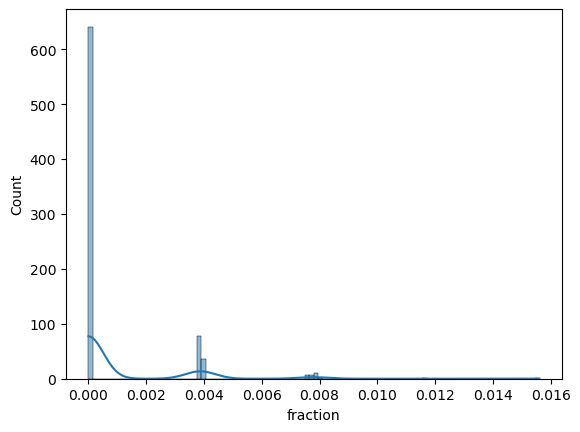

In [16]:
sns.histplot(data[(data['group'] == (0,0)) & (data['u'] == 0.75)]['fraction'],bins=100,kde = True)

In [13]:
n_boot = 1000
sample_N = data['true_N'][0]
sample_T1 = data['true_T1'][0]
sample_T2 = data['true_T2'][0]
sample_T3 = data['true_T3'][0]
columns = ['group','mean_fraction','bootstrap_variance','p_0','true_N','u','v','true_T1','true_T2','true_T3']
boot_data = pd.DataFrame(columns = columns)
for name, group in grouped:
    gg = name[0]
    u = name[1]
    v = name[2]
    non_zero = [i for i in group['fraction'] if i > 0]
    p_0 = 1- (len(non_zero)/len(group['fraction']))
    if p_0 > 0.95:
        continue
    sample_mean = sum(non_zero)/len(non_zero)
    bootstrap_means = []

    for _ in range(n_boot):
        sample = np.random.choice(non_zero, size=len(non_zero), replace=True)
        bootstrap_means.append(np.mean(sample))

# Estimate variance
    variance_estimate = np.var(bootstrap_means)
    new_row = [gg,sample_mean,variance_estimate,p_0,sample_N,u,v,sample_T1,sample_T2,sample_T3]
    boot_data.loc[len(boot_data)] = new_row



In [17]:
def int_p_L(N, t1, t2, u, v):
    cu = -(1/N + u/50)
    cv = -(1/N + v/50)

    # Avoid division by zero or very small denominators

    k1 = (u / (50 * N)) * ((np.exp(cu * t2) * (cu * t2 - 1) / cu**2) - (np.exp(cu * t1) * (cu * t1 - 1) / cu**2))
    k2 = (v / (50 * N)) * ((np.exp(cv * t2) * (cv * t2 - 1) / cv**2) - (np.exp(cv * t1) * (cv * t1 - 1) / cv**2))
    k3 = (1 / N) * ((np.exp(cu * t2) / cu) - (np.exp(cu * t1) / cu))
    k4 = (1 / N) * ((np.exp(cv * t2) / cv) - (np.exp(cv * t1) / cv))

    return k1 - k2 + k3 - k4
true_list = []
for a in range(len(L)-1):
    true_list.append(int_p_L(8000,0,10000000,L[a],L[a+1]))

In [18]:
def true(N,u,v):
    return 100* N**2 * (v-u) * (25 * (u+v) + u*v * N)/((N*v + 50)**2 * (N*u + 50)**2) 

In [19]:
from one_population_data import simulate
N = [4000]
L =  [0.85,0.9,0.95,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6,7,8,9,10] 
final_data = pd.DataFrame(columns = ['u','v','total_mean','non_zero_mean','p_0'])

for _ in range(400):
    ibd = simulate(N,L,2,1e7,10)
    data = pd.DataFrame(ibd)
    grouped = data.groupby(['u','v'])
    for name, group in grouped:
        u = name[0]
        v = name[1]
        total_mean = sum(group['fraction'])/len(group['fraction'])
        non_zero = [i for i in group['fraction'] if i > 0]
        p_0 = 1- (len(non_zero)/len(group['fraction']))
        if len(non_zero) ==0:
            sample_mean = 0
        else:
            sample_mean = sum(non_zero)/len(non_zero)
        new_data = [u,v,total_mean,sample_mean,p_0]
        final_data.loc[len(final_data)] = new_data

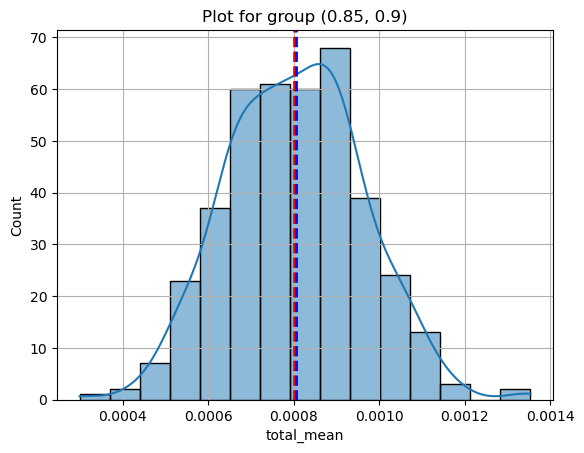

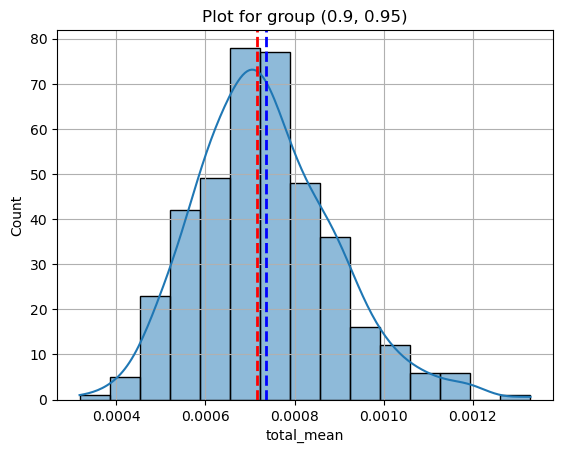

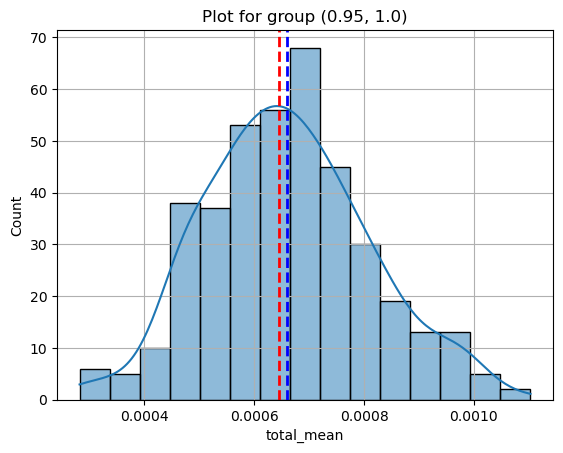

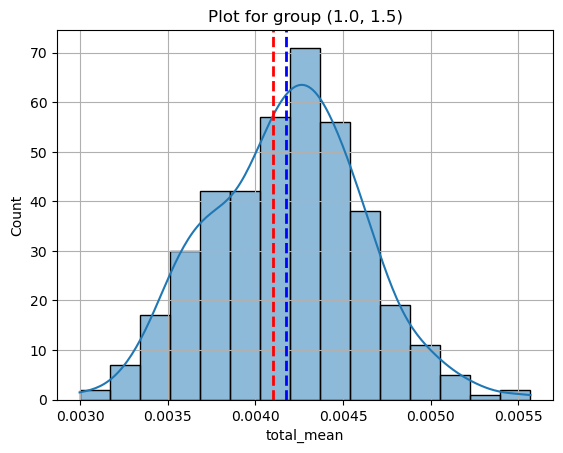

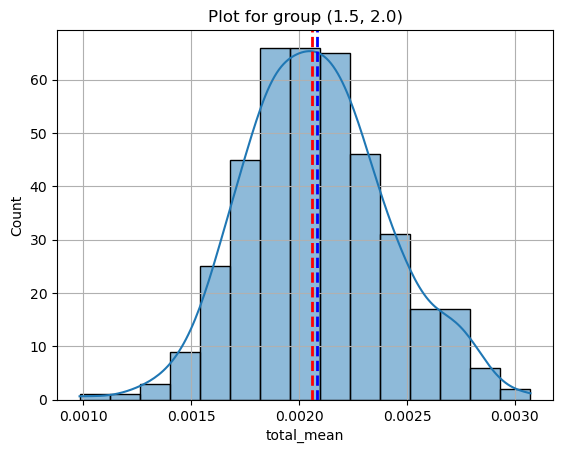

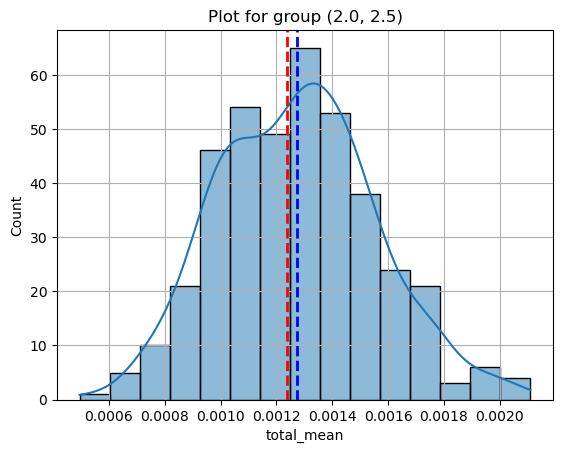

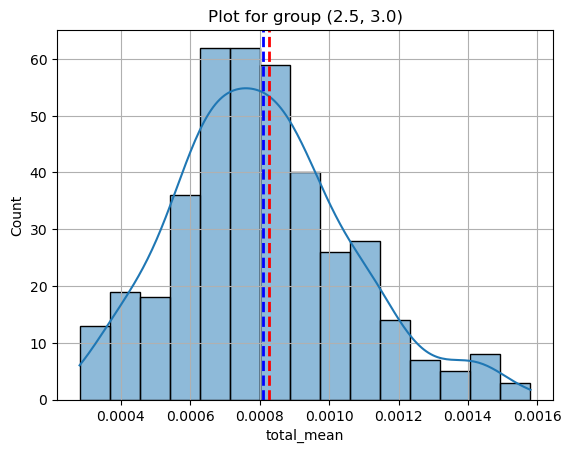

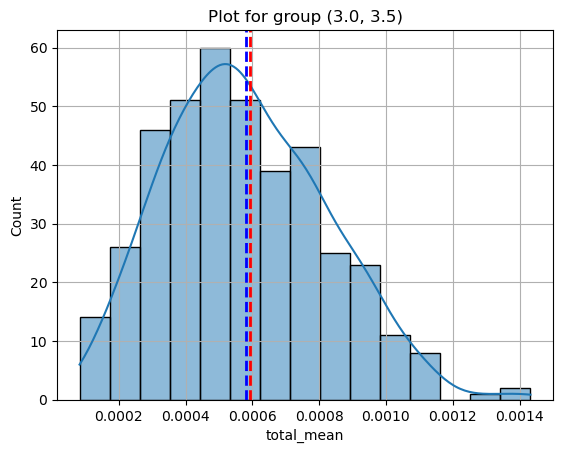

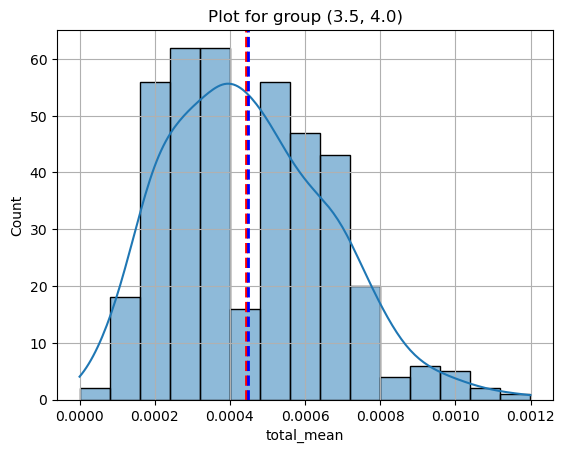

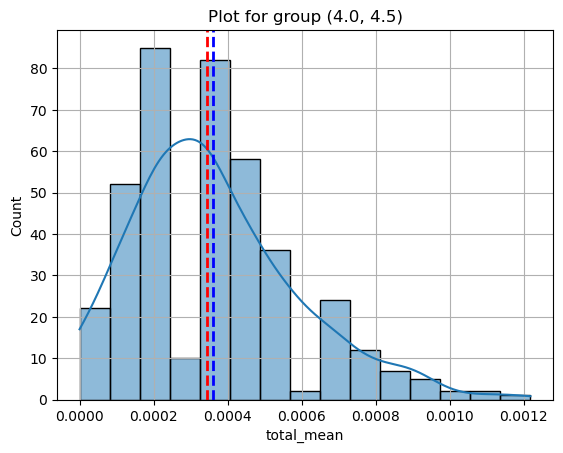

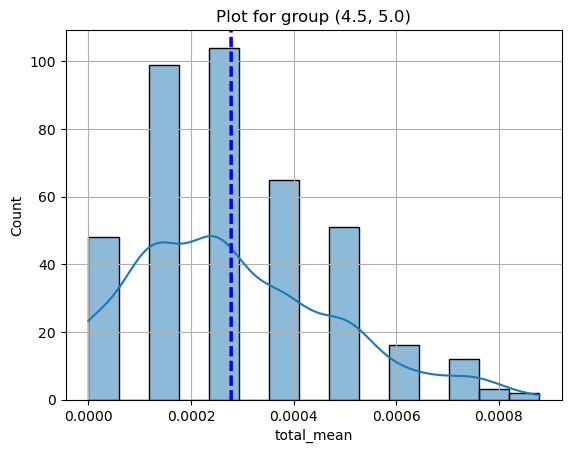

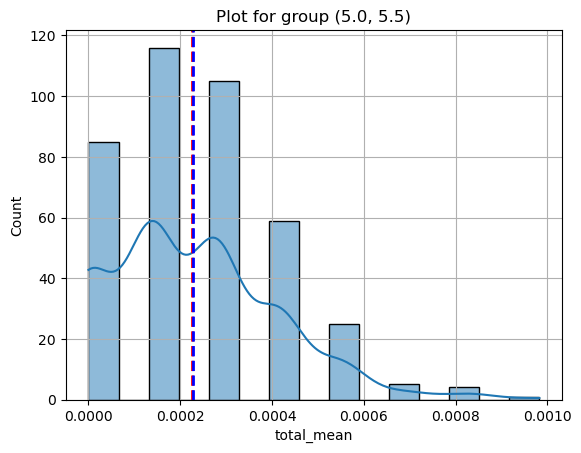

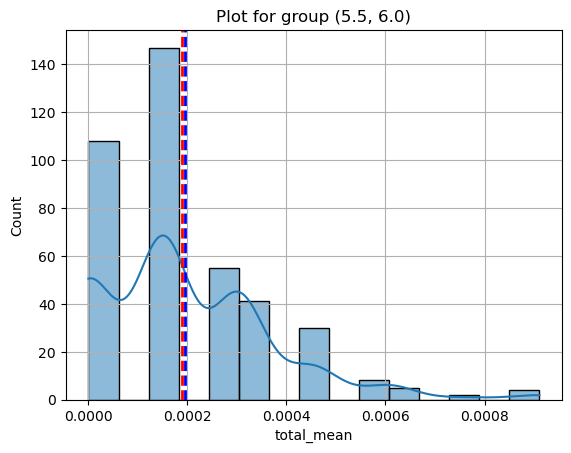

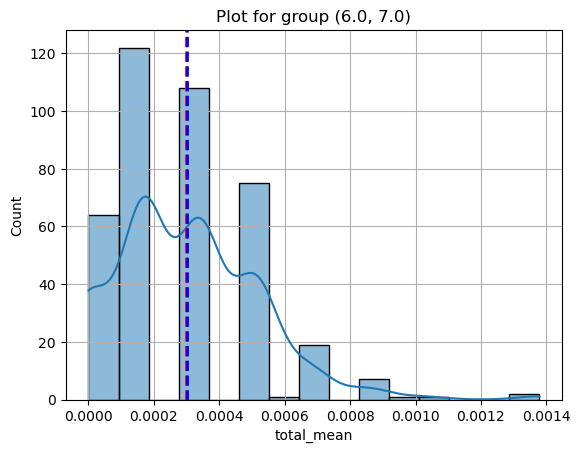

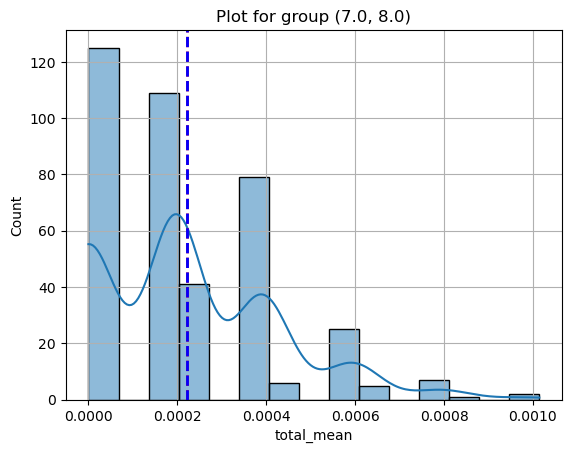

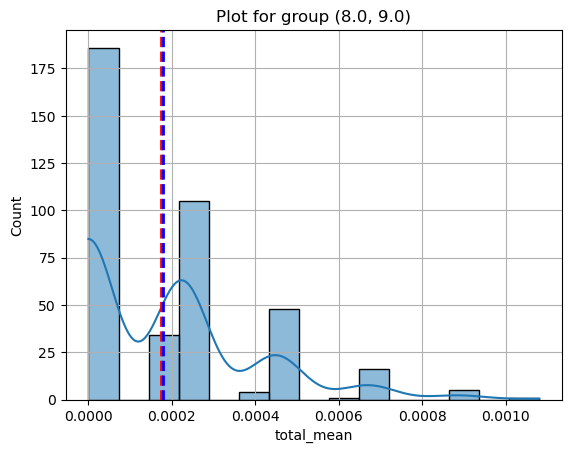

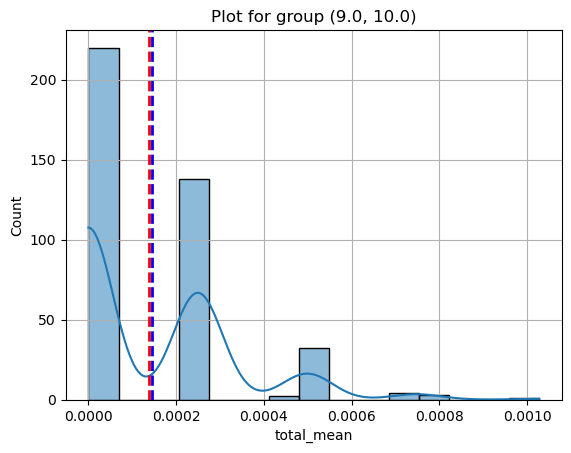

In [20]:
true_list = []
for a in range(len(L)-1):
    true_list.append(int_p_L(8000,0,10000000,L[a],L[a+1]))
gg = final_data.groupby(['u','v'])
i = 0
for name, group in gg:
    plt.figure()
    sns.histplot(group['total_mean'],bins = 15,kde = True)
    plt.title(f'Plot for group {name}')
    plt.axvline(x=true_list[i], color='red', linestyle='--', linewidth=2)
    plt.axvline(x=group['total_mean'].mean(),color = 'blue',linestyle = '--', linewidth=2)
    i += 1
    plt.grid(True)
    plt.show()


In [1]:
i = 0
for name, group in gg:
    plt.figure()
    sns.histplot(group['non_zero_mean'],bins = 15,kde = True)
    plt.title(f'Plot for group {name}')
    plt.axvline(x=true_list[i]/(1-group['p_0'].mean()), color='red', linestyle='--', linewidth=2)
    plt.axvline(x=group[group['non_zero_mean']!=0]['non_zero_mean'].mean(),color = 'blue',linestyle = '--', linewidth=2)

    i += 1
    plt.grid(True)
    plt.show()

NameError: name 'gg' is not defined

In [5]:
from one_population_data import simulate2
N = [4000]
L =  [0.7,0.75,0.8,0.85,0.9,0.95,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6,7,8,10] 
T = 50
cross_data = pd.DataFrame(columns = ['u','v','total_mean','non_zero_mean','p_0'])

for _ in range(200):
    ibd = simulate2(N,T,L,2,1e7,10)
    data = pd.DataFrame(ibd)
    grouped = data.groupby(['u','v'])
    for name, group in grouped:
        u = name[0]
        v = name[1]
        total_mean = sum(group['fraction'])/len(group['fraction'])
        non_zero = [i for i in group['fraction'] if i > 0]
        p_0 = 1- (len(non_zero)/len(group['fraction']))
        if len(non_zero) ==0:
            sample_mean = 0
        else:
            sample_mean = sum(non_zero)/len(non_zero)
        new_data = [u,v,total_mean,sample_mean,p_0]
        cross_data.loc[len(cross_data)] = new_data

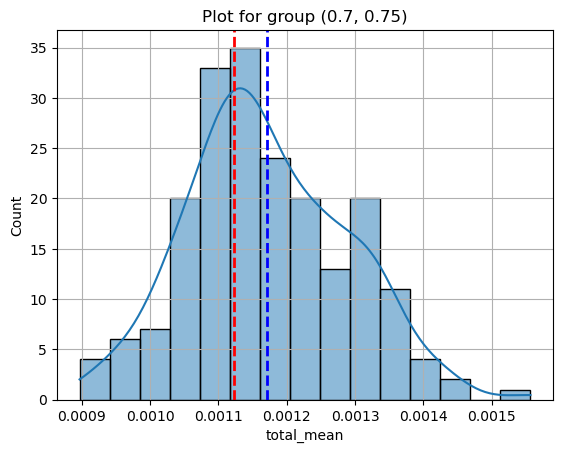

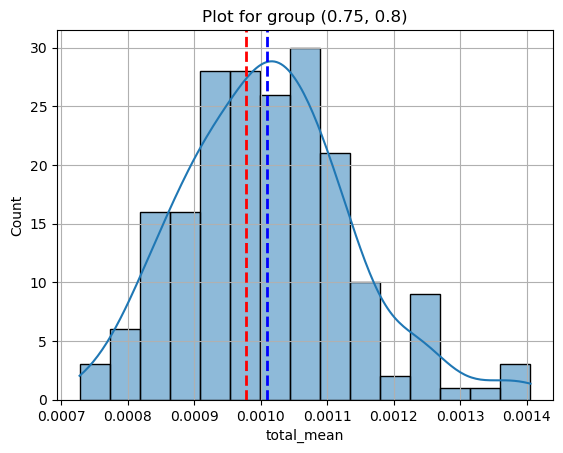

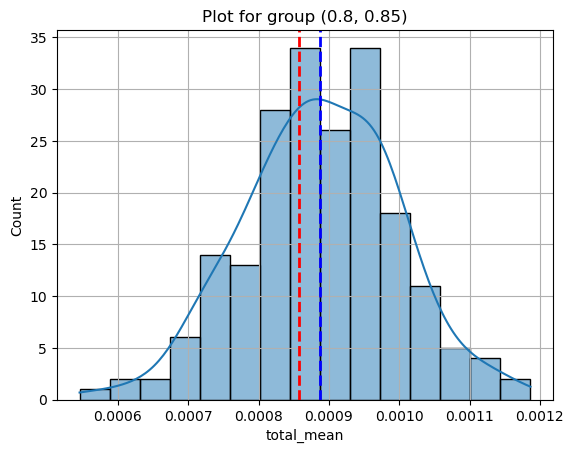

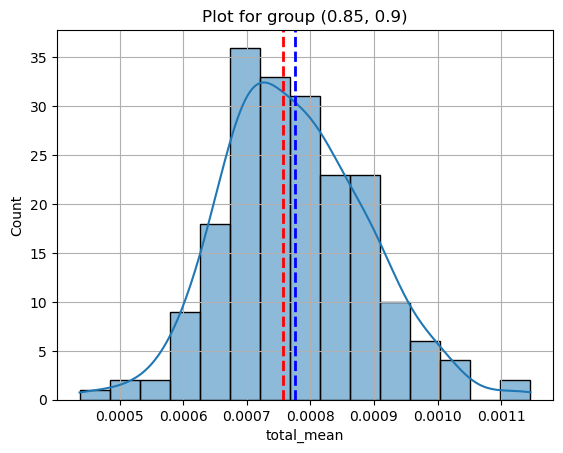

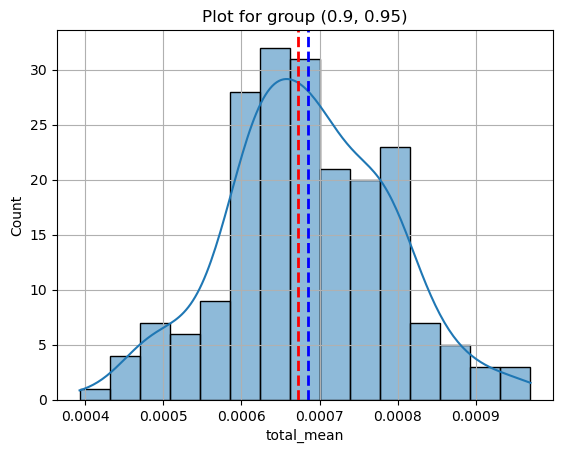

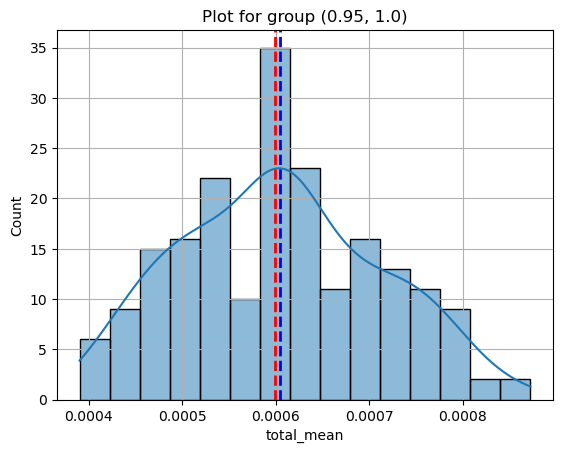

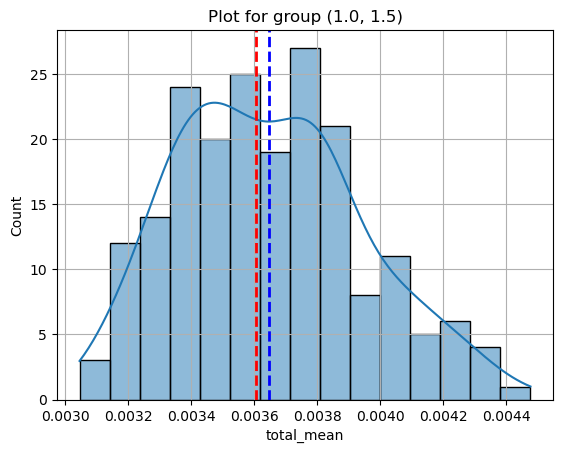

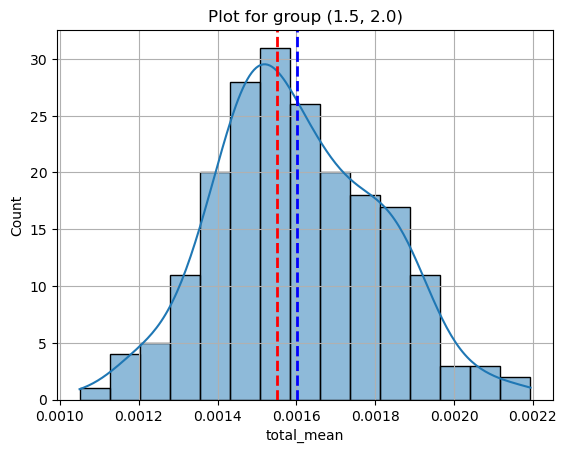

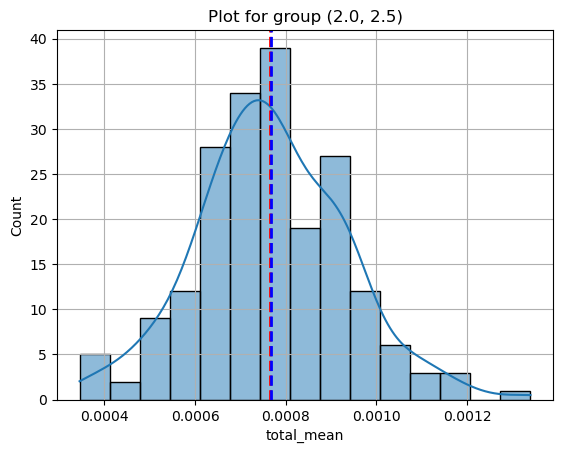

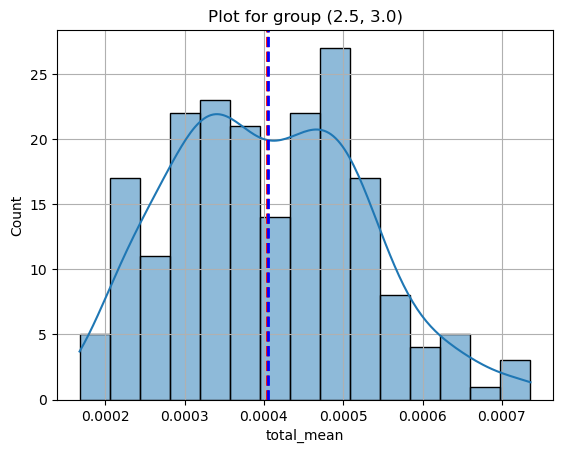

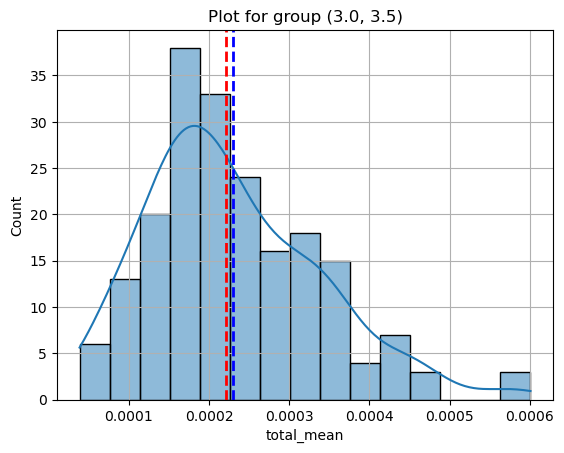

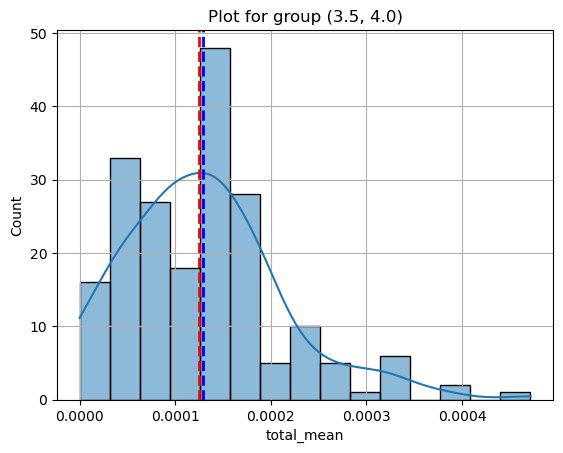

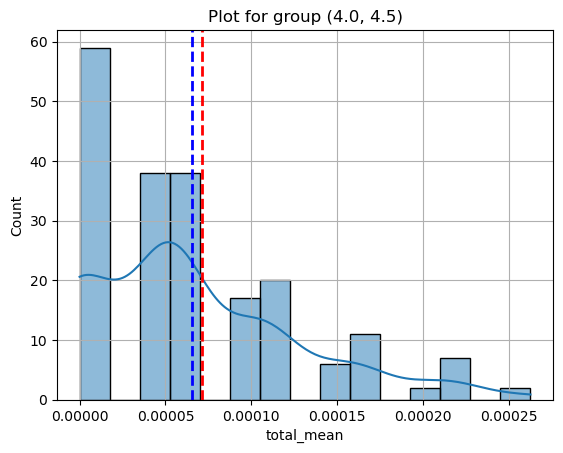

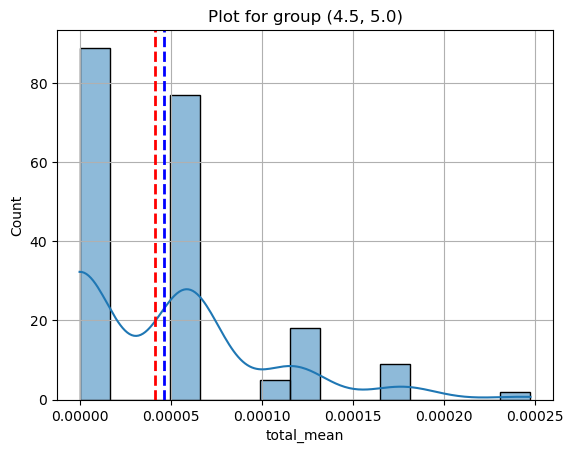

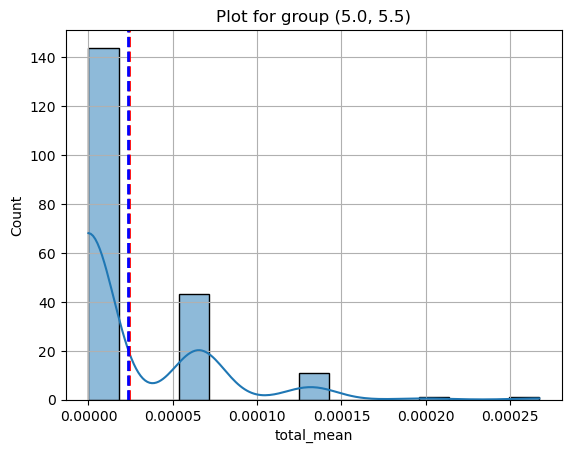

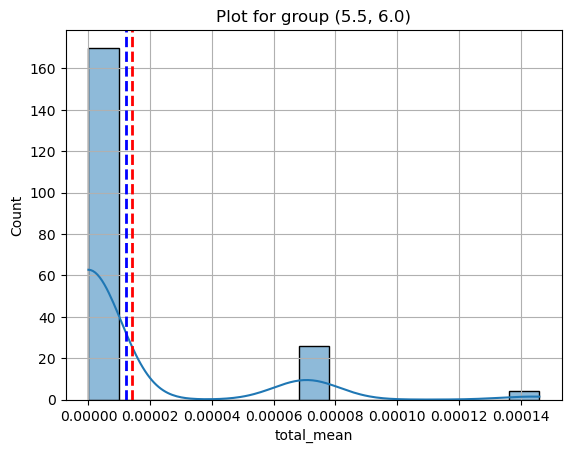

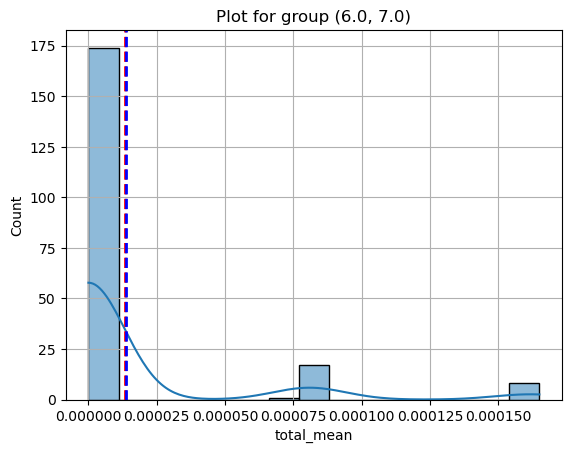

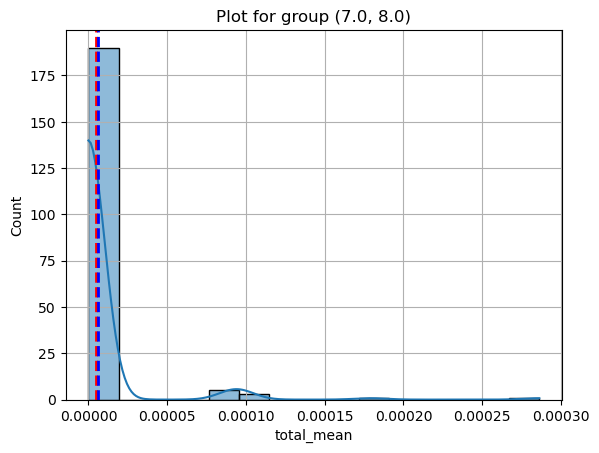

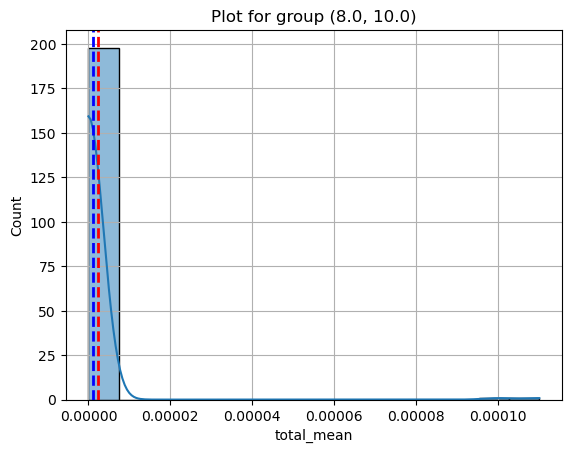

In [18]:
true_list = []
for a in range(len(L)-1):
    true_list.append(np.exp(50/8000) * int_p_L(8000,50,10000000,L[a],L[a+1]))
cross_gg = cross_data.groupby(['u','v'])
i = 0
for name, group in cross_gg:
    plt.figure()
    sns.histplot(group['total_mean'],bins = 15,kde = True)
    plt.title(f'Plot for group {name}')
    plt.axvline(x=true_list[i], color='red', linestyle='--', linewidth=2)
    plt.axvline(x=group['total_mean'].mean(),color = 'blue',linestyle = '--', linewidth=2)
    i += 1
    plt.grid(True)
    plt.show()